**TRABAJO INTELIGENCIA ARTIFICIAL MERYULS Y SALVA**


*Análisis dataset de vuelos de 2024 en EEUU*


En este trabajo, procederemos a realizar un análisis de datos sobre los vuelos del año 2024 en Estados Unidos. De esta forma, intentaremos predecir la columna objetivo que en nuestro caso se correspoderá con la columna de **retraso** , a partir del resto de columnas del dataset. 


Indice del trabajo:


- Creación del dataset mediante joins.
- Limpieza de datos

Primero debemos installar todos los paquetes necesarios e importar todas las librerías necesarias. 

In [2]:
!pip install openpyxl
!pip install siuba
!pip install matplotlib
!pip install seaborn

import pandas as pd
import json
from siuba import _, filter, arrange, select, mutate, group_by, summarize, count
import matplotlib.pyplot as plt
import numpy as np

In [1]:
pip install rpy2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.8/172.8 kB 3.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 10.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


Para formar el dataset final primero partiremos de nuestro conjunto de datos base llamado **'Flight Data 2024'**. Este conjunto de datos está en formato csv y contiene un total de 33 columnas y más de 7 millones de datos. En este datset recaudamos información con todos los vuelos realizados en el país de Estados Unidos durante el año 2024.

In [3]:
vuelos = pd.read_csv("flight_data_2024.csv")
vuelos

/var/folders/cn/vnbd0r_j07x20nbs2_dk9dxm0000gn/T/ipykernel_2964/1589301917.py:1: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  vuelos = pd.read_csv("flight_data_2024.csv")


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7079076,2024,12,31,2,2024-12-31,YX,5857.0,MYR,"Myrtle Beach, SC",South Carolina,...,0,117.0,102.0,76.0,563.0,0,0,0,0,0
7079077,2024,12,31,2,2024-12-31,YX,5859.0,JFK,"New York, NY",New York,...,0,89.0,72.0,51.0,273.0,0,0,0,0,0
7079078,2024,12,31,2,2024-12-31,YX,5859.0,PWM,"Portland, ME",Maine,...,0,89.0,83.0,50.0,273.0,0,0,0,0,0
7079079,2024,12,31,2,2024-12-31,YX,5862.0,JFK,"New York, NY",New York,...,0,89.0,81.0,42.0,209.0,0,0,0,0,0


Además de este conjunto de datos, también utilizaremos un conjunto de datos en formato *json* , que contiene información sobre todos los aeropuertos más concurridos del mundo. Muchos de ellos son de Estados Unidos, por lo que utilizaremos dicha información en nuestro análisis predictivo. Procederemos, entonces a importar los datos json: 

In [4]:
with open('Airports.json', 'r', encoding='utf-8') as file:
    json1 = json.load(file)
print(json.dumps(json1, indent=1, ensure_ascii =False)) 

[
 {
  "Rank": 1,
  "Airport": "United States Hartsfield–Jackson Atlanta International Airport",
  "Location": "Atlanta, Georgia",
  "Country": "United States",
  "Code": "ATL/KATL",
  "Passengers": 104171935,
  "Year": 2016
 },
 {
  "Rank": 2,
  "Airport": "China Beijing Capital International Airport",
  "Location": "Chaoyang-Shunyi, Beijing",
  "Country": "China",
  "Code": "PEK/ZBAA",
  "Passengers": 94393454,
  "Year": 2016
 },
 {
  "Rank": 3,
  "Airport": "United Arab Emirates Dubai International Airport",
  "Location": "Garhoud, Dubai",
  "Country": "United Arab Emirates",
  "Code": "DXB/OMDB",
  "Passengers": 83654250,
  "Year": 2016
 },
 {
  "Rank": 4,
  "Airport": "United States Los Angeles International Airport",
  "Location": "Los Angeles, California",
  "Country": "United States",
  "Code": "LAX/KLAX",
  "Passengers": 80921527,
  "Year": 2016
 },
 {
  "Rank": 5,
  "Airport": "Japan Tokyo Haneda Airport",
  "Location": "Ōta, Tokyo",
  "Country": "Japan",
  "Code": "HND/RJTT"

In [5]:
type(json1)
json1df = pd.json_normalize(json1)
json1df.head()

,Rank,Airport,Location,Country,Code,Passengers,Year
0,1,United States Hartsfield–Jackson Atlanta Inter...,"Atlanta, Georgia",United States,ATL/KATL,104171935,2016
1,2,China Beijing Capital International Airport,"Chaoyang-Shunyi, Beijing",China,PEK/ZBAA,94393454,2016
2,3,United Arab Emirates Dubai International Airport,"Garhoud, Dubai",United Arab Emirates,DXB/OMDB,83654250,2016
3,4,United States Los Angeles International Airport,"Los Angeles, California",United States,LAX/KLAX,80921527,2016
4,5,Japan Tokyo Haneda Airport,"Ōta, Tokyo",Japan,HND/RJTT,79699762,2016


In [6]:
json1df[['Code', 'code_icao']] = json1df['Code'].str.split('/', expand=True)
json1df[['Code', 'code_icao']].head()

,Code,code_icao
0,ATL,KATL
1,PEK,ZBAA
2,DXB,OMDB
3,LAX,KLAX
4,HND,RJTT


In [7]:
json1df

,Rank,Airport,Location,Country,Code,Passengers,Year,code_icao
0,1,United States Hartsfield–Jackson Atlanta Inter...,"Atlanta, Georgia",United States,ATL,104171935,2016,KATL
1,2,China Beijing Capital International Airport,"Chaoyang-Shunyi, Beijing",China,PEK,94393454,2016,ZBAA
2,3,United Arab Emirates Dubai International Airport,"Garhoud, Dubai",United Arab Emirates,DXB,83654250,2016,OMDB
3,4,United States Los Angeles International Airport,"Los Angeles, California",United States,LAX,80921527,2016,KLAX
4,5,Japan Tokyo Haneda Airport,"Ōta, Tokyo",Japan,HND,79699762,2016,RJTT
5,6,United States O'Hare International Airport,"Chicago, Illinois",United States,ORD,78327479,2016,KORD
6,7,United Kingdom Heathrow Airport,"Hillingdon, London",United Kingdom,LHR,75715474,2016,EGLL
7,8,Hong Kong Hong Kong International Airport,"Chek Lap Kok, Islands, New Territories","Hong Kong SAR, China",HKG,70314462,2016,VHHH
8,9,China Shanghai Pudong International Airport,"Pudong, Shanghai",China,PVG,66002414,2016,ZSPD
9,10,France Charles de Gaulle Airport,"Roissy-en-France, Île-de-France",France,CDG,65933145,2016,LFPG


Por último, utilizaremos un *Excel* que contiene información sobre los aeropuertos de Estados Unidos por lo que también estará bien incluirlas en nuestro DataFrame base para posible análisis posteriores. Cargamos dichos datos en un Dataframe.

In [8]:
data = pd.ExcelFile('us-airports.xlsx')
data

In [9]:
df_airports = data.parse(0) 
df_airports.head()

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,country_name,iso_country,...,scheduled_service,gps_code,icao_code,iata_code,local_code,home_link,wikipedia_link,keywords,score,last_updated
0,3632,KLAX,large_airport,Los Angeles International Airport,33.942501,-118.407997,125.0,NaN,United States,US,...,1,KLAX,KLAX,LAX,LAX,https://www.flylax.com/,https://en.wikipedia.org/wiki/Los_Angeles_Inte...,Tom Bradley,1335475.0,2024-04-02T16:36:13+00:00
1,3754,KORD,large_airport,Chicago O'Hare International Airport,41.978600,-87.904800,680.0,NaN,United States,US,...,1,KORD,KORD,ORD,ORD,https://www.flychicago.com/ohare/home/pages/de...,https://en.wikipedia.org/wiki/O'Hare_Internati...,"CHI, Orchard Place",1503175.0,2024-03-09T23:28:49+00:00
2,3622,KJFK,large_airport,John F. Kennedy International Airport,40.639447,-73.779317,13.0,NaN,United States,US,...,1,KJFK,KJFK,JFK,JFK,https://www.jfkairport.com/,https://en.wikipedia.org/wiki/John_F._Kennedy_...,"Manhattan, New York City, NYC, Idlewild, IDL, ...",1052075.0,2026-01-12T15:26:18+00:00
3,3384,KATL,large_airport,Hartsfield Jackson Atlanta International Airport,33.636700,-84.428101,1026.0,NaN,United States,US,...,1,KATL,KATL,ATL,ATL,https://www.atl.com,https://en.wikipedia.org/wiki/Hartsfield–Jacks...,NaN,2002475.0,2025-09-12T16:52:18+00:00
4,3878,KSFO,large_airport,San Francisco International Airport,37.619806,-122.374821,13.0,NaN,United States,US,...,1,KSFO,KSFO,SFO,SFO,http://www.flysfo.com/,https://en.wikipedia.org/wiki/San_Francisco_In...,"QSF, QBA",1112475.0,2024-04-02T16:43:50+00:00


**MODIFICACIÓN EN LOS DATOS**

1. Rellenar los nan de la columna de score poniendo el de delante.
2. Renombrando schuled_service


In [10]:
df_airports['score'] = df_airports['score'].fillna(method='ffill')
print(df_airports['score'].isna().sum())

0


In [11]:
df_airports['scheduled_service'] = df_airports['scheduled_service'].replace({
    1: 'Servicio programado',
    0: 'Sin servicio programado'
})

Ahora que tenemos los tres conjuntos de datos que necesitamos, procederemos a hacer **joins** para poder unirlos todo en una sola tabla. Para unir ambos conjunto de datos, haremos un innerjoin a la izquierda utilizando las columnas 'origin' , 'Code' y 'local_code' que contienen los códigos de los aeropuertos. 

In [12]:
vuelos_final = vuelos.merge(json1df, left_on='origin', right_on='Code', how='left') \
                    .merge(df_airports, left_on='origin', right_on='local_code', how='left')

In [13]:
vuelos_final

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,scheduled_service,gps_code,icao_code,iata_code,local_code,home_link,wikipedia_link,keywords,score,last_updated
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,Servicio programado,KJFK,KJFK,JFK,JFK,https://www.jfkairport.com/,https://en.wikipedia.org/wiki/John_F._Kennedy_...,"Manhattan, New York City, NYC, Idlewild, IDL, ...",1052075.0,2026-01-12T15:26:18+00:00
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,Servicio programado,KMSP,KMSP,MSP,MSP,https://www.mspairport.com/,https://en.wikipedia.org/wiki/Minneapolis–Sain...,NaN,1085275.0,2026-01-29T02:19:46+00:00
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,Servicio programado,KJFK,KJFK,JFK,JFK,https://www.jfkairport.com/,https://en.wikipedia.org/wiki/John_F._Kennedy_...,"Manhattan, New York City, NYC, Idlewild, IDL, ...",1052075.0,2026-01-12T15:26:18+00:00
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,Servicio programado,KRIC,KRIC,RIC,RIC,https://flyrichmond.com/,https://en.wikipedia.org/wiki/Richmond_Interna...,NaN,1475.0,2024-04-29T19:03:07+00:00
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,Servicio programado,KDTW,KDTW,DTW,DTW,http://www.metroairport.com/,https://en.wikipedia.org/wiki/Detroit_Metropol...,"DTT, Detroit Metro Airport",1079375.0,2025-02-28T21:28:04+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7079076,2024,12,31,2,2024-12-31,YX,5857.0,MYR,"Myrtle Beach, SC",South Carolina,...,Servicio programado,KMYR,KMYR,MYR,MYR,https://www.flymyrtlebeach.com,https://en.wikipedia.org/wiki/Myrtle_Beach_Int...,NaN,1000.0,2026-01-12T15:16:45+00:00
7079077,2024,12,31,2,2024-12-31,YX,5859.0,JFK,"New York, NY",New York,...,Servicio programado,KJFK,KJFK,JFK,JFK,https://www.jfkairport.com/,https://en.wikipedia.org/wiki/John_F._Kennedy_...,"Manhattan, New York City, NYC, Idlewild, IDL, ...",1052075.0,2026-01-12T15:26:18+00:00
7079078,2024,12,31,2,2024-12-31,YX,5859.0,PWM,"Portland, ME",Maine,...,Servicio programado,KPWM,KPWM,PWM,PWM,https://portlandjetport.org/,https://en.wikipedia.org/wiki/Portland_Interna...,NaN,1275.0,2026-01-27T01:55:57+00:00
7079079,2024,12,31,2,2024-12-31,YX,5862.0,JFK,"New York, NY",New York,...,Servicio programado,KJFK,KJFK,JFK,JFK,https://www.jfkairport.com/,https://en.wikipedia.org/wiki/John_F._Kennedy_...,"Manhattan, New York City, NYC, Idlewild, IDL, ...",1052075.0,2026-01-12T15:26:18+00:00


**COMPROBACIÓN DEL MERGE**

Voy a coger una pequeña muestra de columnas para poder comprobar si los joins se han efectuado de forma correcta. 

In [14]:
columnas_test = [
    'origin',           
    'Code',             
    'local_code',       
]

display(vuelos_final[columnas_test].sample(15))

,origin,Code,local_code
656482,DCA,NaN,DCA
856504,MSP,MSP,MSP
415899,DAY,NaN,DAY
4236397,PDX,NaN,PDX
3362913,SFO,SFO,SFO
975620,MSP,MSP,MSP
1687312,LAS,LAS,LAS
2906569,BNA,NaN,BNA
4517097,SAN,NaN,SAN
682437,DEN,DEN,DEN


In [15]:
vuelos_final.shape

(7079081, 67)

Aunque dispongamos de unos datasets muy completos, en total tenemos 66 columnas y algunas de ellas son irrelevantes para el objetivo de este trabajo, por lo que a continuación observaremos las columnas y quitaremos algunas de ellas de nuestro dataset para ahorrarnos información de más y no perder eficacia en la rapidz del programa almacenando datos que no usaremos. 

In [16]:
print(vuelos_final.columns)

Index(['year', 'month', 'day_of_month', 'day_of_week', 'fl_date',
       'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city_name',
       'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm',
       'crs_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off',
       'wheels_on', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay',
       'cancelled', 'cancellation_code', 'diverted', 'crs_elapsed_time',
       'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay',
       'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay',
       'Rank', 'Airport', 'Location', 'Country', 'Code', 'Passengers', 'Year',
       'code_icao', 'id', 'ident', 'type', 'name', 'latitude_deg',
       'longitude_deg', 'elevation_ft', 'continent', 'country_name',
       'iso_country', 'region_name', 'iso_region', 'local_region',
       'municipality', 'scheduled_service', 'gps_code', 'icao_code',
       'iata_code', 'local_code', 'home_link', 'wikipedia_link', 'k

In [17]:
columnas_a_eliminar = [
    'Location', 'Country', 'Code', 'id', 'ident', 
    'continent', 'iso_country', 'iso_region', 'local_region', 
    'municipality', 'scheduled_service', 'gps_code', 'icao_code', 
    'iata_code', 'local_code', 'keywords', 'last_updated', 'country_name', 'Year'
    , 'name', 'elevation_ft', 'home_link', 'wikipedia_link', 'region_name', 'cancellation_code']

vuelos = vuelos_final.drop(columns=columnas_a_eliminar)
vuelos.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,security_delay,late_aircraft_delay,Rank,Airport,Passengers,code_icao,type,latitude_deg,longitude_deg,score
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,0,16.0,United States John F. Kennedy International Ai...,58813103.0,KJFK,large_airport,40.639447,-73.779317,1052075.0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,0,49.0,United States Minneapolis/St Paul Internationa...,37413728.0,KMSP,large_airport,44.880081,-93.221741,1085275.0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,0,16.0,United States John F. Kennedy International Ai...,58813103.0,KJFK,large_airport,40.639447,-73.779317,1052075.0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,0,NaN,NaN,NaN,NaN,large_airport,37.505199,-77.319702,1475.0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,0,NaN,NaN,NaN,NaN,large_airport,42.213770,-83.353786,1079375.0


In [18]:
print(vuelos.columns)

Index(['year', 'month', 'day_of_month', 'day_of_week', 'fl_date',
       'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city_name',
       'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm',
       'crs_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off',
       'wheels_on', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay',
       'cancelled', 'diverted', 'crs_elapsed_time', 'actual_elapsed_time',
       'air_time', 'distance', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay', 'Rank', 'Airport',
       'Passengers', 'code_icao', 'type', 'latitude_deg', 'longitude_deg',
       'score'],
      dtype='object')


Vamos a recolectar un resumen de la información principal del dataset y donde observamos la tipología de las columnas.

In [19]:
vuelos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079081 entries, 0 to 7079080
Data columns (total 42 columns):
 #   Column               Dtype  
---  ------               -----  
 0   year                 int64  
 1   month                int64  
 2   day_of_month         int64  
 3   day_of_week          int64  
 4   fl_date              object 
 5   op_unique_carrier    object 
 6   op_carrier_fl_num    float64
 7   origin               object 
 8   origin_city_name     object 
 9   origin_state_nm      object 
 10  dest                 object 
 11  dest_city_name       object 
 12  dest_state_nm        object 
 13  crs_dep_time         int64  
 14  dep_time             float64
 15  dep_delay            float64
 16  taxi_out             float64
 17  wheels_off           float64
 18  wheels_on            float64
 19  taxi_in              float64
 20  crs_arr_time         int64  
 21  arr_time             float64
 22  arr_delay            float64
 23  cancelled            int64  
 24

Viendo por encima los datos, observamos que lo mejor es transformar ciertas variables a determinados tipos para ser mas eficientes trabjando y que de esta forma el dataset se ajuste mejor a la tipografía el curso. Por ello:

- Pondremos las variables **'op_unique_carrier', 'origin', 'dest','origin_state_nm'** y **'origin_state_nm'** como variables categóricas. 
- Pondremos las variables **'diverted'** y **'cancelled'** como variables booleanas en vez de quedarnos solamente con 0 y 1. 
- Eliminaremos ciertas columnas que no son útiles para el posterior entrenamiento de nuestro modelo para predecir. 
- Transformamos la variable **'fl_date'** con el comando pd.to_datetime para que lo reconozca como una fecha. 

In [20]:
vuelos = vuelos.rename(columns={
    'op_unique_carrier': 'aerolinea',
})

vuelos['aerolinea'] = vuelos['aerolinea'].astype('category')
vuelos['origin'] = vuelos['origin'].astype('category')
vuelos['dest'] = vuelos['dest'].astype('category')
vuelos['origin_state_nm'] = vuelos['origin_state_nm'].astype('category')
vuelos['dest_state_nm'] = vuelos['dest_state_nm'].astype('category')

vuelos['cancelled'] = vuelos['cancelled'].astype(bool)
vuelos['diverted'] = vuelos['diverted'].astype(bool)

vuelos['is_delayed'] = (vuelos['arr_delay'] > 15).astype(int)
vuelos['fl_date'] = pd.to_datetime(vuelos['fl_date'])

In [21]:
def clasificar_retraso(minutos):
    if minutos <= 0:
        return 'Sin retraso'
    elif minutos <= 7:
        return 'Casi sin retraso'
    elif minutos <= 15:
        return 'Retraso leve'
    elif minutos <= 60:
        return 'Retraso moderado'
    else:
        return 'Retraso grave'

vuelos['tipo_retraso'] = vuelos['arr_delay'].apply(clasificar_retraso)

print(vuelos['tipo_retraso'].value_counts())
print(vuelos['tipo_retraso'].value_counts(normalize=True).round(3) * 100)

tipo_retraso
Sin retraso         4443259
Retraso moderado     900657
Casi sin retraso     655407
Retraso grave        616545
Retraso leve         463213
Name: count, dtype: int64
tipo_retraso
Sin retraso         62.8
Retraso moderado    12.7
Casi sin retraso     9.3
Retraso grave        8.7
Retraso leve         6.5
Name: proportion, dtype: float64


Observamos la información del nuevo dataset transformado: 

Procedemos a renombrar la columna **'op_unique_carrier** con **'aerolineas'** que es un nombre mas identificativo y más útil. 

In [22]:
vuelos['aerolinea'].cat.categories


Index(['9E', 'AA', 'AS', 'B6', 'DL', 'F9', 'G4', 'HA', 'MQ', 'NK', 'OH', 'OO',
       'UA', 'WN', 'YX'],
      dtype='object')

Observamos que la variable **'cancellation_code'** es la única que posee valores perdidos pero como no es una vaiable numérica, no podemos realziar ninguna transformación apropiada ni tampoco tendría sentido. 

Como podemos observar, uno de los valores de esta variable es nan, de ahí que en la información del Dataframe dicha variable sea catalogada como **float64**.

In [23]:
vuelos.to_feather('vuelos_2024_limpio.feather')

In [24]:
vuelos = pd.read_feather('vuelos_2024_limpio.feather')
vuelos

,year,month,day_of_month,day_of_week,fl_date,aerolinea,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,Rank,Airport,Passengers,code_icao,type,latitude_deg,longitude_deg,score,is_delayed,tipo_retraso
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,16.0,United States John F. Kennedy International Ai...,58813103.0,KJFK,large_airport,40.639447,-73.779317,1052075.0,0,Sin retraso
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,49.0,United States Minneapolis/St Paul Internationa...,37413728.0,KMSP,large_airport,44.880081,-93.221741,1085275.0,0,Sin retraso
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,16.0,United States John F. Kennedy International Ai...,58813103.0,KJFK,large_airport,40.639447,-73.779317,1052075.0,0,Sin retraso
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,NaN,None,NaN,None,large_airport,37.505199,-77.319702,1475.0,0,Sin retraso
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,NaN,None,NaN,None,large_airport,42.213770,-83.353786,1079375.0,0,Sin retraso
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7079076,2024,12,31,2,2024-12-31,YX,5857.0,MYR,"Myrtle Beach, SC",South Carolina,...,NaN,None,NaN,None,large_airport,33.679699,-78.928299,1000.0,0,Sin retraso
7079077,2024,12,31,2,2024-12-31,YX,5859.0,JFK,"New York, NY",New York,...,16.0,United States John F. Kennedy International Ai...,58813103.0,KJFK,large_airport,40.639447,-73.779317,1052075.0,0,Sin retraso
7079078,2024,12,31,2,2024-12-31,YX,5859.0,PWM,"Portland, ME",Maine,...,NaN,None,NaN,None,large_airport,43.646198,-70.309303,1275.0,0,Sin retraso
7079079,2024,12,31,2,2024-12-31,YX,5862.0,JFK,"New York, NY",New York,...,16.0,United States John F. Kennedy International Ai...,58813103.0,KJFK,large_airport,40.639447,-73.779317,1052075.0,0,Sin retraso


Vamos a importar siuba, que como vimos en clase, es una librería parecida al Tidyverse de R para poder trabajar con ella.  Como estamos acostumbrados a R, esta librería nos resultará familiar.

**RESUMEN ESTADÍSTICO DE LA VARIABLE RETRASO**

In [25]:
vuelos['arr_delay'].describe()

count    6.965267e+06
mean     7.098245e+00
std      5.799127e+01
min     -1.260000e+02
25%     -1.500000e+01
50%     -6.000000e+00
75%      9.000000e+00
max      3.803000e+03
Name: arr_delay, dtype: float64

In [26]:
def pct70(column):
    return column.quantile(0.7)

vuelos["arr_delay"].agg(pct70)

5.0

**ESTADISTICAS DE RETRASO AGRUPADAS POR AEROLÍNEA**

In [27]:
df_resumen1 = vuelos.groupby("aerolinea")[["dep_delay","arr_delay"]].mean()
df_resumen2 = vuelos.groupby("aerolinea")[["dep_delay", "arr_delay"]].agg([min, max, sum])
df_resumen = pd.concat([df_resumen1, df_resumen2], axis=1)
df_resumen

,dep_delay,arr_delay,"(dep_delay, min)","(dep_delay, max)","(dep_delay, sum)","(arr_delay, min)","(arr_delay, max)","(arr_delay, sum)"
aerolinea,,,,,,,,
9E,8.336984,1.681912,-39.0,1279.0,1631356.0,-69.0,1305.0,328094.0
AA,20.698095,15.307916,-31.0,3777.0,20069473.0,-89.0,3803.0,14789223.0
AS,7.634071,4.467858,-88.0,927.0,1841315.0,-82.0,917.0,1073729.0
B6,17.458447,10.739642,-41.0,2521.0,4131751.0,-95.0,2512.0,2531151.0
DL,10.223549,3.657075,-59.0,1278.0,10226084.0,-91.0,1278.0,3649198.0
F9,19.002299,15.247771,-47.0,1388.0,3876412.0,-84.0,1432.0,3102647.0
G4,14.047917,9.710381,-44.0,1534.0,1618587.0,-91.0,1575.0,1115548.0
HA,5.468065,4.246661,-25.0,1729.0,425071.0,-78.0,1734.0,329681.0
MQ,10.176118,6.457716,-32.0,2212.0,2810186.0,-61.0,2196.0,1777919.0


Primero vamos a empezar, utizando la librería panda para poder hacer un poco de plotting inicial de forma que podamos visualizar los datos y estudiarlos un poco mejor antes de empezar a predecir. 

**PLOTTING PREVIO SOBRE NUESTRO DATASET**

Procedemos primero a realizar un histograma sobre la cantidad de retrasos de nuestro dataset:


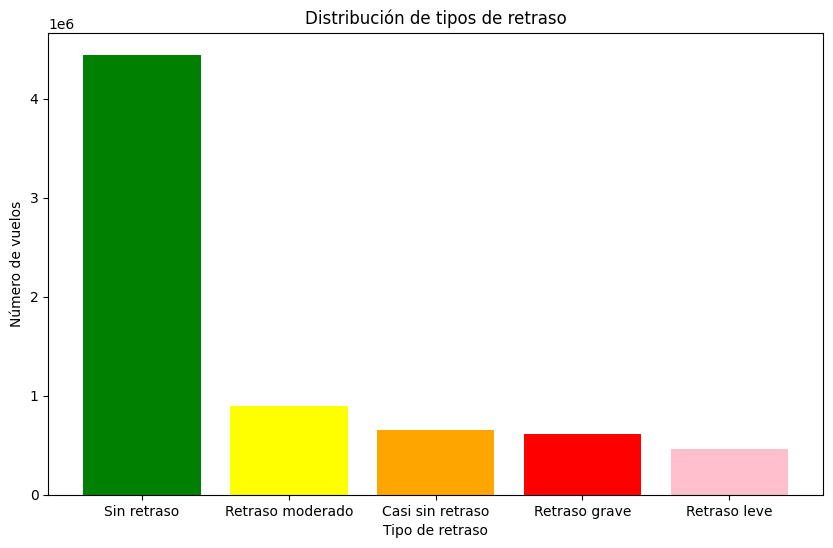

In [30]:
conteos = vuelos['tipo_retraso'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(conteos.index, conteos.values, color=['green', 'yellow', 'orange', 'red','pink'])
ax.set_title('Distribución de tipos de retraso')
ax.set_xlabel('Tipo de retraso')
ax.set_ylabel('Número de vuelos')
plt.show()

Utilizando R vemos cuáles son los valores outliers tanto de retraso como de llegada anticipada. 
Gracias al boxplot y los outliers de R, observamos que los valores outliers por la cola de la derecha son: 
- Retraso de 3803 minutos.
- Llegada anticipada de 126 minutos.

In [33]:
import calendar

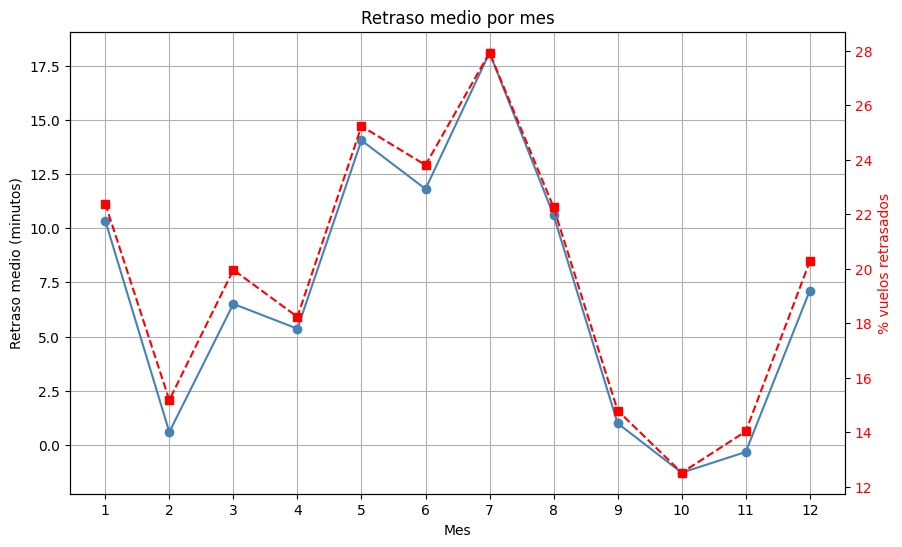

In [36]:
retraso_mes = vuelos.groupby('month')['arr_delay'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot((retraso_mes.index), retraso_mes.values, marker='o', color='steelblue')
ax.set_title('Retraso medio por mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Retraso medio (minutos)')
ax.set_xticks(range(1, 13))
ax.grid(True)

pct_retrasados = vuelos.groupby('month')['is_delayed'].mean() * 100
ax2 = ax.twinx()
ax2.plot((retraso_mes.index), pct_retrasados.values, 
         color='red', marker='s', linestyle='--', label='% retrasados')
ax2.set_ylabel('% vuelos retrasados', color='red')
ax2.tick_params(axis='y', labelcolor='red')
 
plt.show()

Es importante conocer el total de vuelos realizados por cada aerolínea por lo que utilizando un diagrama de barras, representamos esta información.

Realizamos un plot scatter que analice la regresión lineal entre las variables de tiempo de retraso en total del vuelo y al despegar.

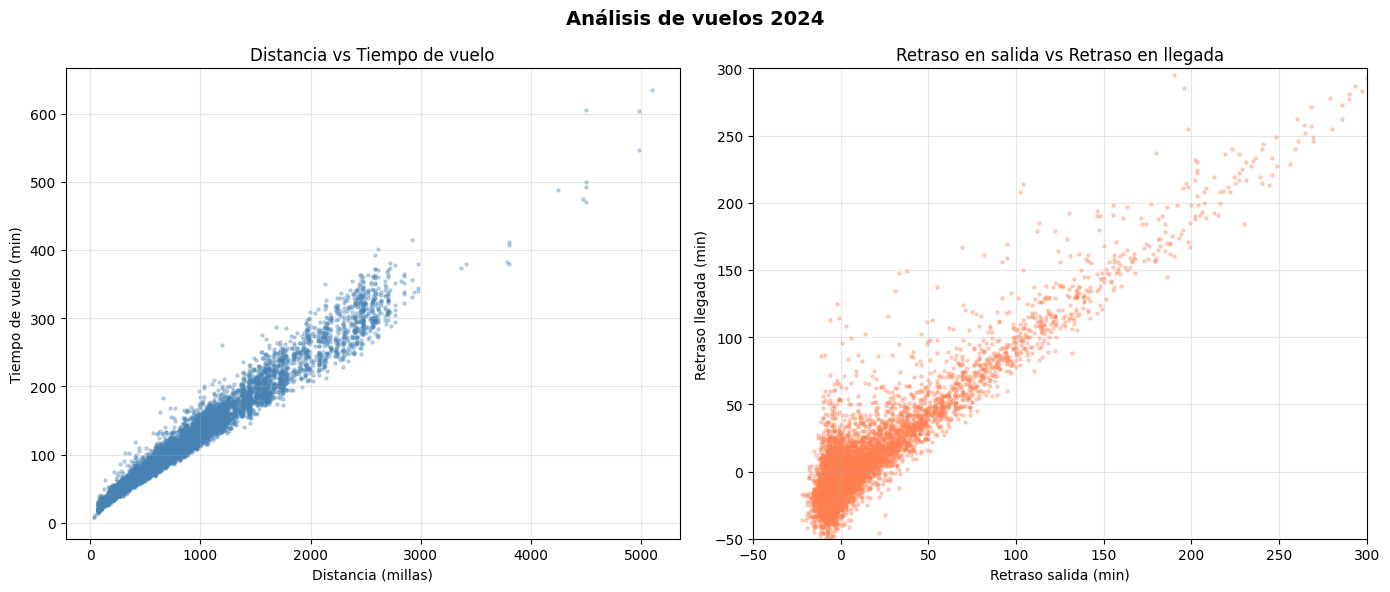

In [ ]:
muestra = vuelos.sample(n=10000, random_state=42)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(muestra['distance'], muestra['air_time'], 
            alpha=0.3, s=5, color='steelblue')
ax1.set_title('Distancia vs Tiempo de vuelo')
ax1.set_xlabel('Distancia (millas)')
ax1.set_ylabel('Tiempo de vuelo (min)')
ax1.grid(True, alpha=0.3)

ax2.scatter(muestra['dep_delay'], muestra['arr_delay'], 
            alpha=0.3, s=5, color='coral')
ax2.set_title('Retraso en salida vs Retraso en llegada')
ax2.set_xlabel('Retraso salida (min)')
ax2.set_ylabel('Retraso llegada (min)')
ax2.set_xlim(-50, 300)
ax2.set_ylim(-50, 300)
ax2.grid(True, alpha=0.3)

fig.suptitle('Análisis de vuelos 2024', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 1.1 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.4/449.4 kB 1.4 MB/s eta 0:00:00a 0:00:01


In [43]:
import plotly.express as px

retraso_aerolinea = vuelos.groupby('aerolinea')['arr_delay'].mean().reset_index()
retraso_aerolinea.columns = ['aerolinea', 'retraso_medio']
retraso_aerolinea = retraso_aerolinea.sort_values('retraso_medio', ascending=False)

fig = px.bar(retraso_aerolinea, 
             x='aerolinea', y='retraso_medio',
             title='Retraso medio por aerolínea',
             labels={'retraso_medio': 'Retraso medio (min)', 'aerolinea': 'Aerolínea'},
             color='retraso_medio',
             color_continuous_scale='RdYlGn_r')
fig.show()

In [48]:
import plotly.graph_objects as go

causas = {
    'Aerolínea': vuelos['carrier_delay'].sum(),
    'Clima': vuelos['weather_delay'].sum(),
    'Sistema aéreo': vuelos['nas_delay'].sum(),
    'Seguridad': vuelos['security_delay'].sum(),
    'Avión previo': vuelos['late_aircraft_delay'].sum()
}

fig = go.Figure(data=[go.Pie(
    labels=list(causas.keys()),
    values=list(causas.values())
)])
fig.update_layout(title='Causas principales de retraso')
fig.show()

In [52]:
import plotly.express as px

top_4_aerolineas = vuelos['aerolinea'].value_counts().nlargest(4).index

filtro_vuelos = vuelos[
    (vuelos['aerolinea'].isin(top_4_aerolineas)) & 
    (vuelos['arr_delay'].between(-60, 180))
]
muestra = filtro_vuelos.sample(n=min(50000, len(filtro_vuelos)), random_state=42)

fig = px.violin(muestra, 
                y='arr_delay', 
                x='aerolinea',
                title='Distribución de retrasos para las 4 aerolíneas principales',
                labels={'arr_delay': 'Retraso en llegada (min)', 
                        'aerolinea': 'Aerolínea'},
                box=True, 
                points=False)

fig.show()

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from siuba import *

In [79]:
vuelos

,year,month,day_of_month,day_of_week,fl_date,aerolinea,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,Airport,Passengers,code_icao,type,latitude_deg,longitude_deg,score,is_delayed,tipo_retraso,nombre_mes
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,United States John F. Kennedy International Ai...,58813103.0,KJFK,large_airport,40.639447,-73.779317,1052075.0,0,Sin retraso,January
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,United States Minneapolis/St Paul Internationa...,37413728.0,KMSP,large_airport,44.880081,-93.221741,1085275.0,0,Sin retraso,January
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,United States John F. Kennedy International Ai...,58813103.0,KJFK,large_airport,40.639447,-73.779317,1052075.0,0,Sin retraso,January
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,None,NaN,None,large_airport,37.505199,-77.319702,1475.0,0,Sin retraso,January
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,None,NaN,None,large_airport,42.213770,-83.353786,1079375.0,0,Sin retraso,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7079076,2024,12,31,2,2024-12-31,YX,5857.0,MYR,"Myrtle Beach, SC",South Carolina,...,None,NaN,None,large_airport,33.679699,-78.928299,1000.0,0,Sin retraso,December
7079077,2024,12,31,2,2024-12-31,YX,5859.0,JFK,"New York, NY",New York,...,United States John F. Kennedy International Ai...,58813103.0,KJFK,large_airport,40.639447,-73.779317,1052075.0,0,Sin retraso,December
7079078,2024,12,31,2,2024-12-31,YX,5859.0,PWM,"Portland, ME",Maine,...,None,NaN,None,large_airport,43.646198,-70.309303,1275.0,0,Sin retraso,December
7079079,2024,12,31,2,2024-12-31,YX,5862.0,JFK,"New York, NY",New York,...,United States John F. Kennedy International Ai...,58813103.0,KJFK,large_airport,40.639447,-73.779317,1052075.0,0,Sin retraso,December


(array([1066492.,  591767.,  582205.,  609743.,  611132.,  634613.,
         619025.,  582622.,  615497., 1165985.]),
 array([ 0. ,  1.1,  2.2,  3.3,  4.4,  5.5,  6.6,  7.7,  8.8,  9.9, 11. ]),
 <BarContainer object of 10 artists>)

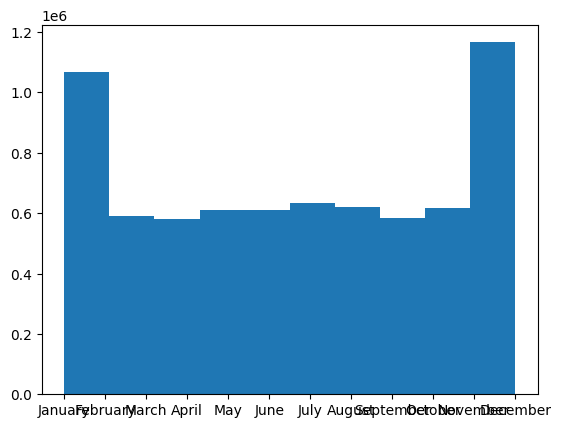

In [50]:
plt.hist(vuelos['nombre_mes'])

**ANÁLISIS NAVIDAD**

In [51]:
vuelos['es_navidad'] = np.where(vuelos['month'].isin([1, 12]), 1, 0)

In [52]:
from siuba.dply.vector import * 

In [53]:
(vuelos
  >> filter(_.cancelled == 0)
  >> group_by(_.es_navidad)
  >> summarize(
       retraso_minimo  = _.arr_delay.min(),
       retraso_maximo  = _.arr_delay.max(),
       retraso_medio   = _.arr_delay.mean(),
       n_vuelos        = n(_)
     )
)

,es_navidad,retraso_minimo,retraso_maximo,retraso_medio,n_vuelos
0,0,-117.0,3803.0,6.804445,5869454
1,1,-126.0,3241.0,8.647714,1113312


**MAPA DE CALOR DE LAS VARIABLES**

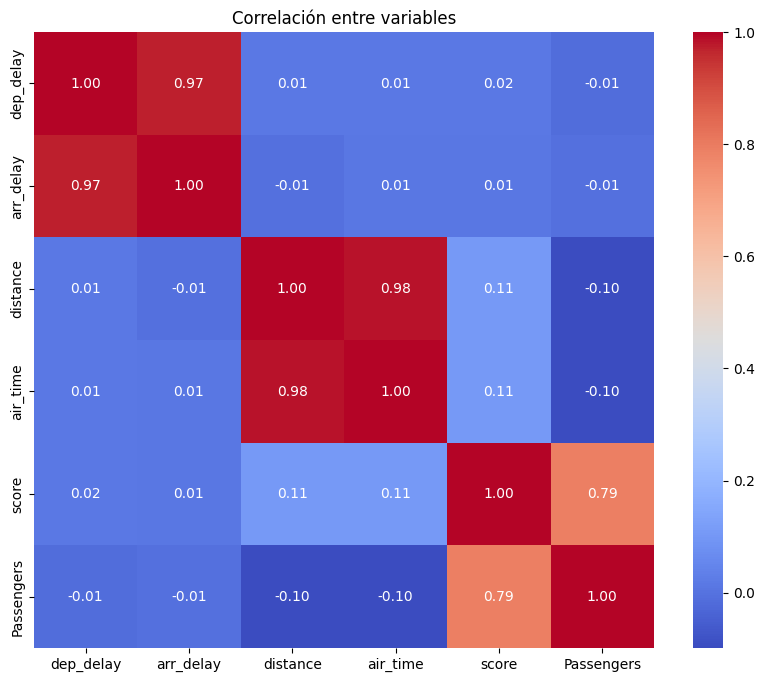

In [65]:
import seaborn as sns

columnas_numericas = ['dep_delay', 'arr_delay', 'distance', 
                'air_time', 'score', 'Passengers']

plt.figure(figsize=(10,8))
sns.heatmap(vuelos[columnas_numericas].corr(), 
            annot=True, 
            cmap='coolwarm',
            fmt='.2f')
plt.title("Correlación entre variables")
plt.show()

**RETRASO MEDIO SEGÚN LA HORA DE SALIDA**

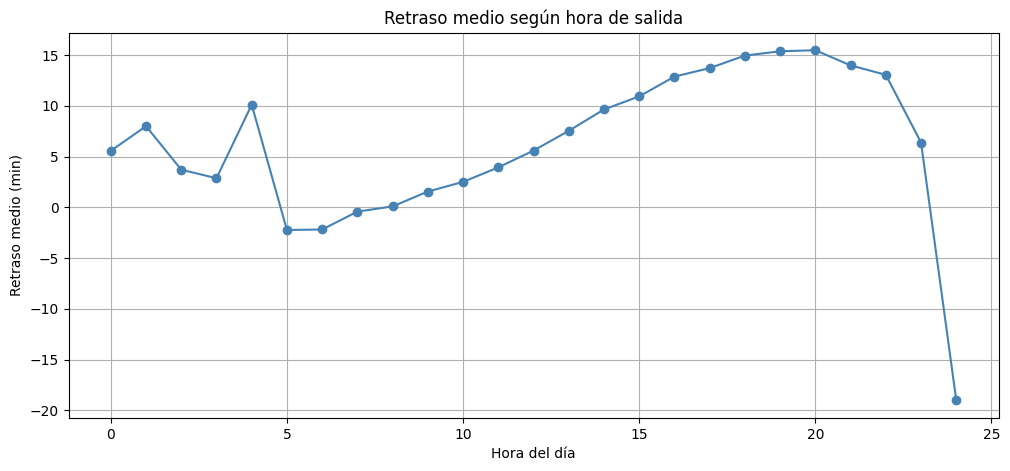

In [ ]:
vuelos['hora_salida'] = vuelos['crs_dep_time'] // 100

vuelos.groupby('hora_salida')['arr_delay'].mean().plot(
    kind='line', 
    figsize=(12,5),
    marker='o',
    color='steelblue')

plt.title("Retraso medio según hora de salida")
plt.xlabel("Hora del día")
plt.ylabel("Retraso medio (min)")
plt.grid(True)
plt.show()

**TOP RUTAS CON MAS RETRASO**

In [56]:
top_rutas = (vuelos
    >> filter(_.cancelled == 0)
    >> group_by(_.origin_city_name, _.dest_city_name)
    >> summarize(retraso_medio = _.arr_delay.mean(), n_vuelos = n(_))
    >> filter(_.n_vuelos > 1000)
) 

top_rutas.sort_values(
    by=['retraso_medio', 'n_vuelos'], 
    ascending=[False, False]
).head(10)[['origin_city_name', 'dest_city_name', 'retraso_medio', 'n_vuelos']]

,origin_city_name,dest_city_name,retraso_medio,n_vuelos
4346,"Pensacola, FL","Dallas/Fort Worth, TX",28.767730,1705
5322,"San Juan, PR","Philadelphia, PA",28.221668,1413
1554,"Dallas/Fort Worth, TX","Madison, WI",26.973231,1048
6040,"Valparaiso, FL","Dallas/Fort Worth, TX",26.957934,1361
3285,"Madison, WI","Dallas/Fort Worth, TX",26.836852,1048
6198,"West Palm Beach/Palm Beach, FL","Dallas/Fort Worth, TX",26.217470,1104
1500,"Dallas/Fort Worth, TX","Des Moines, IA",25.805858,1197
1559,"Dallas/Fort Worth, TX","Milwaukee, WI",25.544490,1229
1837,"Des Moines, IA","Dallas/Fort Worth, TX",24.603694,1196
2840,"Key West, FL","Charlotte, NC",24.466426,1396


**NA (VALORES PERDIDOS) EN EL DATAFRAME**

In [57]:
vuelos.isna().any()
vuelos.isna().sum()
vuelos = vuelos.dropna(subset=['arr_delay'])
vuelos.isna().sum()

year                         0
month                        0
day_of_month                 0
day_of_week                  0
fl_date                      0
aerolinea                    0
op_carrier_fl_num            1
origin                       0
origin_city_name             0
origin_state_nm              0
dest                         0
dest_city_name               0
dest_state_nm                0
crs_dep_time                 0
dep_time                     0
dep_delay                    0
taxi_out                     0
wheels_off                   0
wheels_on                    0
taxi_in                      0
crs_arr_time                 0
arr_time                     0
arr_delay                    0
cancelled                    0
cancellation_code      6965267
diverted                     0
crs_elapsed_time             0
actual_elapsed_time          0
air_time                     0
distance                     0
carrier_delay                0
weather_delay                0
nas_dela

**ESTADÍSTICAS UTILIZANDO TÉCNICAS DE MAPEO**

Construir diccionario de aerolineas y tiempos totales de retraso

In [91]:
# Aerolíneas ordenadas de mayor a menor retraso medio
(vuelos
  >> filter(_.cancelled == 0)
  >> group_by(_.aerolinea)
  >> summarize(retraso_medio = _.arr_delay.mean().round(1))
  >> arrange(-_.retraso_medio)
)

,aerolinea,retraso_medio
1,AA,15.3
5,F9,15.2
3,B6,10.7
10,OH,10.0
6,G4,9.7
9,NK,8.4
11,OO,7.4
8,MQ,6.5
12,UA,5.7
13,WN,5.1


**ESTADÍSTICAS BÁSICAS PARA CADA AEROLÍNEA**

In [58]:

aerolineas_datos = dict(vuelos.groupby('aerolinea')['arr_delay'].apply(list))
aerolineas_datos

estadisticas_aerolineas = dict(map(
    lambda item: (
        item[0],  
        {
            'media': np.mean(item[1]),
            'mediana': np.median(item[1]),
            'std': np.std(item[1]),
            'min': min(item[1]),
            'max': max(item[1]),
            'cv': np.std(item[1]) / np.mean(item[1])  
        }
    ),
    aerolineas_datos.items()
))

for aerolinea, stats in estadisticas_aerolineas.items():
    print(f"\n{aerolinea}:")
    print(f"  Media: {stats['media']:.1f} min, Mediana: {stats['mediana']:.1f} min")
    print(f"  Variabilidad (CV): {stats['cv']:.3f}")


9E:
  Media: 1.7 min, Mediana: -11.0 min
  Variabilidad (CV): 33.448

AA:
  Media: 15.3 min, Mediana: -4.0 min
  Variabilidad (CV): 5.481

AS:
  Media: 4.5 min, Mediana: -4.0 min
  Variabilidad (CV): 8.069

B6:
  Media: 10.7 min, Mediana: -6.0 min
  Variabilidad (CV): 6.062

DL:
  Media: 3.7 min, Mediana: -8.0 min
  Variabilidad (CV): 14.367

F9:
  Media: 15.2 min, Mediana: -4.0 min
  Variabilidad (CV): 4.828

G4:
  Media: 9.7 min, Mediana: -8.0 min
  Variabilidad (CV): 8.186

HA:
  Media: 4.2 min, Mediana: -1.0 min
  Variabilidad (CV): 8.605

MQ:
  Media: 6.5 min, Mediana: -6.0 min
  Variabilidad (CV): 7.577

NK:
  Media: 8.4 min, Mediana: -6.0 min
  Variabilidad (CV): 6.235

OH:
  Media: 10.0 min, Mediana: -6.0 min
  Variabilidad (CV): 7.269

OO:
  Media: 7.4 min, Mediana: -7.0 min
  Variabilidad (CV): 8.578

UA:
  Media: 5.7 min, Mediana: -7.0 min
  Variabilidad (CV): 9.196

WN:
  Media: 5.1 min, Mediana: -5.0 min
  Variabilidad (CV): 6.884

YX:
  Media: -1.8 min, Mediana: -11.0 mi

**MESES CON MAYOR RETRASO SEGÚN LA AEROLÍNEA**

In [ ]:
retraso_por_aerolinea_mes = {}
for aerolinea, grupo in vuelos.groupby('aerolinea'):
    retraso_por_aerolinea_mes[aerolinea] = grupo.groupby('nombre_mes')['arr_delay'].mean().to_dict()

umbral = 15

meses_problematicos = {
    aerolinea: [
        {'mes': nombre_mes, 'retraso_medio': round(retraso, 1)}
        for nombre_mes, retraso in info_meses.items()
        if retraso > umbral
    ]
    for aerolinea, info_meses in retraso_por_aerolinea_mes.items()
}

print(f"Aerolíneas con meses de retraso medio > {umbral} min:")
for aerolinea, meses in meses_problematicos.items():
    if meses:
        detalles = ', '.join([f"{m['mes']} ({m['retraso_medio']})" for m in meses])
        print(f"  {aerolinea}: {detalles}")

Aerolíneas con meses de retraso medio > 15 min:
  9E: July (19.8)
  AA: August (21.6), January (19.2), July (31.8), June (23.0), March (16.5), May (30.2)
  B6: August (26.1), December (15.7), July (18.7), June (15.4), March (17.6)
  DL: July (22.6)
  F9: April (18.6), August (18.6), July (22.2), June (24.7), March (21.7), May (20.9)
  G4: December (18.0), July (20.2)
  MQ: May (21.4)
  NK: August (16.2), July (21.5)
  OH: August (15.3), December (16.4), July (28.0), May (17.4)
  OO: January (15.2)
  UA: July (17.6)


**EVOLUCIÓN DE LOS RETRASOS SEGÚN EL MES**

In [ ]:
resumen_mensual = vuelos.groupby('month').agg({
    'arr_delay': 'mean',
    'nombre_mes': 'first'  
}).reset_index()

retrasos = resumen_mensual['arr_delay'].tolist()
nombres = resumen_mensual['nombre_mes'].tolist()

cambios_mensuales = []
for i in range(len(retrasos) - 1):
    mes_actual = nombres[i]
    mes_siguiente = nombres[i+1]
    retraso_actual = retrasos[i]
    retraso_siguiente = retrasos[i+1]
    
    cambio_valor = retraso_siguiente - retraso_actual
    pct = (cambio_valor / abs(retraso_actual)) * 100
    
    cambios_mensuales.append({
        'de_mes': mes_actual,
        'a_mes': mes_siguiente,
        'cambio': round(cambio_valor, 1),
        'pct_cambio': round(pct, 1)
    })

print("Evolución del retraso mes a mes:")
for c in cambios_mensuales:
    direccion = "↑" if c['cambio'] > 0 else "↓"
    print(f"  {c['de_mes']} → {c['a_mes']}: {direccion} {c['cambio']:+.1f} min ({c['pct_cambio']:+.1f}%)")

Evolución del retraso mes a mes:
  January → February: ↓ -9.8 min (-94.3%)
  February → March: ↑ +5.9 min (+996.0%)
  March → April: ↓ -1.1 min (-17.6%)
  April → May: ↑ +8.7 min (+162.1%)
  May → June: ↓ -2.2 min (-16.0%)
  June → July: ↑ +6.3 min (+53.2%)
  July → August: ↓ -7.5 min (-41.5%)
  August → September: ↓ -9.6 min (-90.6%)
  September → October: ↓ -2.3 min (-228.7%)
  October → November: ↑ +1.0 min (+74.7%)
  November → December: ↑ +7.4 min (+2292.3%)


**AEROLÍNEA CON MÁS PORCENTAJE DE VUELOS RETRASADOS POR MES**

In [77]:
datos_por_mes = vuelos.groupby(['month', 'aerolinea'])['is_delayed'].mean() * 100
datos_por_mes = datos_por_mes.unstack()

peor_aerolinea_por_mes = list(map(
    lambda item: {
        'mes': item[0],
        'aerolinea': item[1].idxmax(),
        'pct_retrasados': round(item[1].max(), 1)
    },
    datos_por_mes.iterrows()
))

print("Aerolínea con mayor % de vuelos retrasados por mes:")
for item in peor_aerolinea_por_mes:
    print(f"  {calendar.month_name[int(item['mes'])]}: {item['aerolinea']} ({item['pct_retrasados']}%)")

Aerolínea con mayor % de vuelos retrasados por mes:
  January: AA (28.6%)
  February: B6 (23.9%)
  March: F9 (31.1%)
  April: F9 (29.0%)
  May: AA (36.1%)
  June: F9 (35.5%)
  July: AA (37.2%)
  August: B6 (35.4%)
  September: F9 (23.2%)
  October: F9 (23.6%)
  November: F9 (21.7%)
  December: B6 (30.0%)


**PEOR DATO DE TODOS LOS RETRASOS**

In [80]:
from functools import reduce

peor_mes_aerolinea = reduce(
    lambda acc, item: acc if acc['pct_retrasados'] > item['pct_retrasados'] else item,
    peor_aerolinea_por_mes
)

print(f"\nPeor mes y aerolínea de todo el año:")
print(f"  {calendar.month_name[int(peor_mes_aerolinea['mes'])]} - {peor_mes_aerolinea['aerolinea']} "
      f"con un {peor_mes_aerolinea['pct_retrasados']}% de vuelos retrasados")


Peor mes y aerolínea de todo el año:
  July - AA con un 37.2% de vuelos retrasados


**PORCENTAJES DE CADA AEROLÍNEA POR MES**

In [ ]:
retrasos_por_aerolinea = {}
aerolineas = list(datos_por_mes.columns)

for aerolinea in aerolineas:
    retrasos_por_aerolinea[aerolinea] = dict(map(
        lambda item: (calendar.month_name[item[0]-1], item[1]),
        datos_por_mes[aerolinea].items()
    ))

print("Retrasos de AA a lo largo del año:")
for mes, pct in retrasos_por_aerolinea['AA'].items():
    print(f"  {mes}: {pct:.1f}%") 

analisis_aerolineas = dict(map(
    lambda item: (
        item[0],  
        {
            'media': round(np.mean(list(item[1].values())), 1),
            'tendencia': round(list(item[1].values())[-1] - list(item[1].values())[0], 1),
            'peor_mes': max(item[1].items(), key=lambda x: x[1]),
            'mejor_mes': min(item[1].items(), key=lambda x: x[1])
        }
    ),
    retrasos_por_aerolinea.items()
))

print("\nAnálisis por aerolínea:")
for aerolinea, analisis in analisis_aerolineas.items():
    print(f"\n{aerolinea}:")
    print(f"  Media anual: {analisis['media']}% de vuelos retrasados")
    print(f"  Tendencia (Dic-Ene): {analisis['tendencia']:+.1f}%")
    print(f"  Peor mes: {analisis['peor_mes'][0]} ({analisis['peor_mes'][1]:.1f}%)")
    print(f"  Mejor mes: {analisis['mejor_mes'][0]} ({analisis['mejor_mes'][1]:.1f}%)")

Retrasos de AA a lo largo del año:
  : 28.6%
  January: 18.0%
  February: 26.3%
  March: 23.4%
  April: 36.1%
  May: 31.4%
  June: 37.2%
  July: 30.3%
  August: 18.7%
  September: 15.2%
  October: 15.8%
  November: 22.0%

Análisis por aerolínea:

9E:
  Media anual: 15.4% de vuelos retrasados
  Tendencia (Dic-Ene): -3.7%
  Peor mes: June (28.2%)
  Mejor mes: September (7.6%)

AA:
  Media anual: 25.3% de vuelos retrasados
  Tendencia (Dic-Ene): -6.6%
  Peor mes: June (37.2%)
  Mejor mes: September (15.2%)

AS:
  Media anual: 21.1% de vuelos retrasados
  Tendencia (Dic-Ene): -5.9%
  Peor mes:  (26.8%)
  Mejor mes: October (16.1%)

B6:
  Media anual: 24.8% de vuelos retrasados
  Tendencia (Dic-Ene): +1.8%
  Peor mes: July (35.4%)
  Mejor mes: September (13.6%)

DL:
  Media anual: 16.6% de vuelos retrasados
  Tendencia (Dic-Ene): +0.7%
  Peor mes: June (29.2%)
  Mejor mes: September (9.2%)

F9:
  Media anual: 27.8% de vuelos retrasados
  Tendencia (Dic-Ene): -2.8%
  Peor mes: May (35.5%)
  

**CLASIFICACIÓN DE LOS MESES POR NIVEL DE RETRASO**

In [87]:
retraso_mensual = vuelos.groupby('month')['arr_delay'].mean().tolist()

def clasificar_cuartil(valor, todos_valores):
    q25, q50, q75 = np.percentile(todos_valores, [25, 50, 75])
    if valor <= q25:
        return 'Q1 - Muy puntual'
    elif valor <= q50:
        return 'Q2 - Puntual'
    elif valor <= q75:
        return 'Q3 - Retrasado'
    else:
        return 'Q4 - Muy retrasado'

clasificacion_meses = list(map(
    lambda item: {
        'mes': calendar.month_name[item[0]+1],
        'retraso': round(item[1], 1),
        'cuartil': clasificar_cuartil(item[1], retraso_mensual)
    },
    enumerate(retraso_mensual)
))

print("Clasificación de meses por nivel de retraso:")
for item in clasificacion_meses:
    print(f"  {item['mes']}: {item['retraso']} min → {item['cuartil']}")

Clasificación de meses por nivel de retraso:
  January: 10.4 min → Q3 - Retrasado
  February: 0.6 min → Q1 - Muy puntual
  March: 6.5 min → Q2 - Puntual
  April: 5.4 min → Q2 - Puntual
  May: 14.0 min → Q4 - Muy retrasado
  June: 11.8 min → Q4 - Muy retrasado
  July: 18.1 min → Q4 - Muy retrasado
  August: 10.6 min → Q3 - Retrasado
  September: 1.0 min → Q2 - Puntual
  October: -1.3 min → Q1 - Muy puntual
  November: -0.3 min → Q1 - Muy puntual
  December: 7.1 min → Q3 - Retrasado


In [ ]:
def crear_informe_aerolinea(aerolinea, datos):
    """Genera un informe completo para una aerolínea"""
    valores = list(datos.values())
    meses = list(datos.keys())
    return {
        'aerolinea': aerolinea,
        'pct_medio_anual': round(np.mean(valores), 1),
        'peor_mes': {
            'nombre': meses[valores.index(max(valores))],
            'pct': round(max(valores), 1)
        },
        'mejor_mes': {
            'nombre': meses[valores.index(min(valores))],
            'pct': round(min(valores), 1)
        },
        'variabilidad': round(np.std(valores), 1),
        'retrasos_por_trimestre': [
            round(np.mean(valores[0:3]), 1),   # Q1: Ene-Mar
            round(np.mean(valores[3:6]), 1),   # Q2: Abr-Jun
            round(np.mean(valores[6:9]), 1),   # Q3: Jul-Sep
            round(np.mean(valores[9:12]), 1)   # Q4: Oct-Dic
        ],
        'tendencia': 'empeora' if valores[-1] > valores[0] else 'mejora'
    }

informes_aerolineas = list(map(
    lambda item: crear_informe_aerolinea(item[0], item[1]),
    retrasos_por_aerolinea.items()
))

# Mostrar informe completo
print("=" * 70)
print("INFORME COMPLETO DE RETRASOS POR AEROLÍNEA — 2024")
print("=" * 70)

for informe in informes_aerolineas:
    print(f"\n{informe['aerolinea']}:")
    print(f"  Media anual de retrasos: {informe['pct_medio_anual']}%")
    print(f"  Peor mes: {informe['peor_mes']['nombre']} ({informe['peor_mes']['pct']}%)")
    print(f"  Mejor mes: {informe['mejor_mes']['nombre']} ({informe['mejor_mes']['pct']}%)")
    print(f"  Variabilidad (σ): {informe['variabilidad']}")
    print(f"  Retrasos por trimestre: Q1={informe['retrasos_por_trimestre'][0]}%, "
          f"Q2={informe['retrasos_por_trimestre'][1]}%, "
          f"Q3={informe['retrasos_por_trimestre'][2]}%, "
          f"Q4={informe['retrasos_por_trimestre'][3]}%")
    print(f"  Tendencia (Ene→Dic): {informe['tendencia']}")

print("\n" + "=" * 70)
print("CONCLUSIONES CLAVE:")
print("=" * 70)

peor_aerolinea = max(informes_aerolineas, key=lambda x: x['pct_medio_anual'])
mejor_aerolinea = min(informes_aerolineas, key=lambda x: x['pct_medio_anual'])
mas_variable = max(informes_aerolineas, key=lambda x: x['variabilidad'])

print(f"Aerolínea con más retrasos: {peor_aerolinea['aerolinea']} ({peor_aerolinea['pct_medio_anual']}%)")
print(f"Aerolínea más puntual: {mejor_aerolinea['aerolinea']} ({mejor_aerolinea['pct_medio_anual']}%)")
print(f"Aerolínea más irregular: {mas_variable['aerolinea']} (σ={mas_variable['variabilidad']})")
print("=" * 70)

INFORME COMPLETO DE RETRASOS POR AEROLÍNEA — 2024

9E:
  Media anual de retrasos: 15.4%
  Peor mes: June (28.2%)
  Mejor mes: September (7.6%)
  Variabilidad (σ): 6.2
  Retrasos por trimestre: Q1=14.8%, Q2=15.6%, Q3=19.3%, Q4=12.0%
  Tendencia (Ene→Dic): mejora

AA:
  Media anual de retrasos: 25.3%
  Peor mes: June (37.2%)
  Mejor mes: September (15.2%)
  Variabilidad (σ): 7.3
  Retrasos por trimestre: Q1=24.3%, Q2=30.3%, Q3=28.7%, Q4=17.7%
  Tendencia (Ene→Dic): mejora

AS:
  Media anual de retrasos: 21.1%
  Peor mes:  (26.8%)
  Mejor mes: October (16.1%)
  Variabilidad (σ): 3.5
  Retrasos por trimestre: Q1=21.4%, Q2=22.5%, Q3=22.8%, Q4=17.7%
  Tendencia (Ene→Dic): mejora

B6:
  Media anual de retrasos: 24.8%
  Peor mes: July (35.4%)
  Mejor mes: September (13.6%)
  Variabilidad (σ): 6.4
  Retrasos por trimestre: Q1=27.3%, Q2=24.5%, Q3=27.7%, Q4=19.6%
  Tendencia (Ene→Dic): empeora

DL:
  Media anual de retrasos: 16.6%
  Peor mes: June (29.2%)
  Mejor mes: September (9.2%)
  Variabili

**ORDENACION**

Uso el melt para meltera y que quede mas claro

In [ ]:
vuelos_largo = vuelos.melt(
    id_vars=['month', 'aerolinea', 'origin', 'dest', 'is_delayed'],
    value_vars=['carrier_delay', 'weather_delay', 'nas_delay', 
                'security_delay', 'late_aircraft_delay'],
    var_name='tipo_retraso',
    value_name='minutos'
)

vuelos_largo.head(10)

,month,aerolinea,origin,dest,is_delayed,tipo_retraso,minutos
0,1,9E,JFK,DTW,0,carrier_delay,0
1,1,9E,MSP,CLE,0,carrier_delay,0
2,1,9E,JFK,RIC,0,carrier_delay,0
3,1,9E,RIC,JFK,0,carrier_delay,0
4,1,9E,DTW,MKE,0,carrier_delay,0
5,1,9E,JAX,LGA,0,carrier_delay,0
6,1,9E,LGA,JAX,0,carrier_delay,0
7,1,9E,CHS,LGA,0,carrier_delay,0
8,1,9E,LGA,CHS,0,carrier_delay,0
9,1,9E,ITH,JFK,0,carrier_delay,0


In [ ]:
resumen_maximos = vuelos_largo.groupby('tipo_retraso')['minutos'].max().reset_index()

resumen_maximos

,tipo_retraso,minutos
0,carrier_delay,3689
1,late_aircraft_delay,2690
2,nas_delay,2700
3,security_delay,1164
4,weather_delay,1804


In [ ]:
(vuelos
  >> filter(_.cancelled == 0)
  >> group_by(_.origin_city_name, _.dest_city_name, _.aerolinea)
  >> summarize(
      retraso_medio = _.arr_delay.mean().round(1),
      n_vuelos = n(_),
      pct_retrasados = (_.is_delayed.mean() * 100).round(1)
  )
  >> filter(_.n_vuelos > 1000)
  >> arrange(-_.retraso_medio, -_.n_vuelos, -_.pct_retrasados)
)

,origin_city_name,dest_city_name,aerolinea,retraso_medio,n_vuelos,pct_retrasados
9080,"Pensacola, FL","Dallas/Fort Worth, TX",AA,40.7,1012,39.3
10862,"San Francisco, CA","Las Vegas, NV",F9,38.0,1093,46.6
3376,"Dallas/Fort Worth, TX","Pensacola, FL",AA,34.8,1017,41.3
3164,"Dallas/Fort Worth, TX","Des Moines, IA",AA,31.2,1025,39.4
3947,"Des Moines, IA","Dallas/Fort Worth, TX",AA,29.2,1020,31.9
...,...,...,...,...,...,...
8241,"New York, NY","San Francisco, CA",AA,-8.2,1379,15.7
8040,"New York, NY","Chicago, IL",YX,-8.2,1057,10.6
3505,"Dayton, OH","Atlanta, GA",DL,-8.5,1157,8.3
8136,"New York, NY","Louisville, KY",YX,-9.6,1396,11.2


**FUNCIONES**

In [95]:
def retrasos_aerolinea(aerolinea):
    retrasos = dict(map(
        lambda item: (calendar.month_name[item[0]], item[1]),
        datos_por_mes[aerolinea].items()
    ))
    for mes, pct in retrasos.items():
        print(f"  {mes}: {pct:.1f}%")

retrasos_aerolinea('UA')

  January: 21.0%
  February: 15.5%
  March: 18.1%
  April: 18.5%
  May: 25.7%
  June: 23.5%
  July: 28.1%
  August: 22.4%
  September: 12.7%
  October: 11.3%
  November: 16.6%
  December: 18.1%


**FUNCIÓN QUE PARA CADA ORIGEN Y DESTINO TE DICE DATOS RELEVANTES**

In [98]:
def consultar_ruta(origen, destino):
    ruta = vuelos[
        (vuelos['origin'] == origen) & 
        (vuelos['dest'] == destino) &
        (vuelos['cancelled'] == 0)
    ]
    
    if len(ruta) == 0:
        return "No hay datos para esta ruta"
    
    ranking_aerolineas = (ruta
        .groupby('aerolinea')
        .agg(
            pct_retrasados = ('is_delayed', lambda x: round(x.mean() * 100, 1)),
            retraso_medio  = ('arr_delay', lambda x: round(x.mean(), 1)),
            n_vuelos       = ('is_delayed', 'count')
        )
        .reset_index()
        .query('n_vuelos > 0')        # Solo aerolíneas con vuelos en esa ruta
        .dropna()                      # Eliminar NaN
        .sort_values('pct_retrasados', ascending=True)
        .reset_index(drop=True)
    )
    
    return {
        'retraso_medio': round(ruta['arr_delay'].mean(), 1),
        'pct_retrasados': round(ruta['is_delayed'].mean() * 100, 1),
        'mejor_aerolinea': ranking_aerolineas.iloc[0]['aerolinea'],
        'peor_aerolinea': ranking_aerolineas.iloc[-1]['aerolinea'],
        'peor_mes': calendar.month_name[ruta.groupby('month')['is_delayed'].mean().idxmax()],
        'mejor_mes': calendar.month_name[ruta.groupby('month')['is_delayed'].mean().idxmin()],
        'ranking_aerolineas': ranking_aerolineas
    }

consultar_ruta('JFK', 'LAX')

{'retraso_medio': -2.9,
 'pct_retrasados': 16.6,
 'mejor_aerolinea': 'AA',
 'peor_aerolinea': 'DL',
 'peor_mes': 'July',
 'mejor_mes': 'October',
 'ranking_aerolineas':   aerolinea  pct_retrasados  retraso_medio  n_vuelos
 0        AA            13.6           -8.1      3254
 1        B6            17.5           -4.4      3284
 2        DL            18.7            3.5      3321}

In [ ]:
def riesgo_ruta(origen, destino, mes, dia_semana):
    """
    Calcula el riesgo de retraso para una ruta en un momento concreto.
    mes: 1-12
    dia_semana: 1=Lunes ... 7=Domingo
    """
    
    ruta = vuelos[
        (vuelos['origin'] == origen) &
        (vuelos['dest'] == destino) &
        (vuelos['cancelled'] == 0)
    ]
    
    if len(ruta) == 0:
        return "No hay datos para esta ruta"
    
    pct_ruta = ruta['is_delayed'].mean() * 100
    
    ruta_mes = ruta[ruta['month'] == mes]
    pct_mes = ruta_mes['is_delayed'].mean() * 100 if len(ruta_mes) > 0 else pct_ruta
    
    ruta_dia = ruta[ruta['day_of_week'] == dia_semana]
    pct_dia = ruta_dia['is_delayed'].mean() * 100 if len(ruta_dia) > 0 else pct_ruta
    
    pct_final = (pct_ruta * 0.3) + (pct_mes * 0.4) + (pct_dia * 0.3)
    
    # Clasificar riesgo
    if pct_final < 15:
        nivel = 'BAJO'
        emoji = '🟢'
        consejo = 'Buen momento para volar, pocos retrasos esperados'
    elif pct_final < 30:
        nivel = 'MEDIO'
        emoji = '🟡'
        consejo = 'Riesgo moderado, considera salir con margen'
    else:
        nivel = 'ALTO'
        emoji = '🔴'
        consejo = 'Alta probabilidad de retraso, ten precaución'
    
    return {
        'origen': origen,
        'destino': destino,
        'mes': calendar.month_name[mes - 1],
        'dia': ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo'][dia_semana - 1],
        'pct_retraso_estimado': round(pct_final, 1),
        'nivel_riesgo': nivel,
        'emoji': emoji,
        'consejo': consejo
    }

resultado = riesgo_ruta('JFK', 'LAX', mes=7, dia_semana=5)

print(f"{resultado['emoji']} RIESGO {resultado['nivel_riesgo']}")
print(f"Ruta: {resultado['origen']} → {resultado['destino']}")
print(f"Mes: {resultado['mes']} | Día: {resultado['dia']}")
print(f"Probabilidad de retraso estimada: {resultado['pct_retraso_estimado']}%")
print(f"Consejo: {resultado['consejo']}")

🟡 RIESGO MEDIO
Ruta: JFK → LAX
Mes: June | Día: Viernes
Probabilidad de retraso estimada: 21.7%
Consejo: Riesgo moderado, considera salir con margen


In [100]:
def mejor_momento(origen, destino):
    """
    Devuelve el mejor y peor momento para volar una ruta concreta.
    """
    
    ruta = vuelos[
        (vuelos['origin'] == origen) &
        (vuelos['dest'] == destino) &
        (vuelos['cancelled'] == 0)
    ]
    
    if len(ruta) == 0:
        return "No hay datos para esta ruta"
    
    dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
    
    # Mejor y peor mes
    por_mes = ruta.groupby('month')['is_delayed'].mean() * 100
    mejor_mes = calendar.month_name[por_mes.idxmin()]
    peor_mes = calendar.month_name[por_mes.idxmax()]
    
    # Mejor y peor día de la semana
    por_dia = ruta.groupby('day_of_week')['is_delayed'].mean() * 100
    mejor_dia = dias[por_dia.idxmin() - 1]
    peor_dia = dias[por_dia.idxmax() - 1]
    
    # Mejor y peor hora de salida
    ruta = ruta.copy()
    ruta['hora_salida'] = ruta['crs_dep_time'] // 100
    por_hora = ruta.groupby('hora_salida')['is_delayed'].mean() * 100
    mejor_hora = por_hora.idxmin()
    peor_hora = por_hora.idxmax()
    
    return {
        'origen': origen,
        'destino': destino,
        'mejor_mes': mejor_mes,
        'peor_mes': peor_mes,
        'pct_mejor_mes': round(por_mes.min(), 1),
        'pct_peor_mes': round(por_mes.max(), 1),
        'mejor_dia': mejor_dia,
        'peor_dia': peor_dia,
        'pct_mejor_dia': round(por_dia.min(), 1),
        'pct_peor_dia': round(por_dia.max(), 1),
        'mejor_hora': f"{mejor_hora:02d}:00",
        'peor_hora': f"{peor_hora:02d}:00",
        'pct_mejor_hora': round(por_hora.min(), 1),
        'pct_peor_hora': round(por_hora.max(), 1)
    }

# Probar
resultado = mejor_momento('JFK', 'LAX')

print(f"Mejor momento para volar {resultado['origen']} → {resultado['destino']}:")
print(f"\n  Mes:")
print(f"    Mejor: {resultado['mejor_mes']} ({resultado['pct_mejor_mes']}% retrasos)")
print(f"    Peor:  {resultado['peor_mes']} ({resultado['pct_peor_mes']}% retrasos)")
print(f"\n  Día de la semana:")
print(f"    Mejor: {resultado['mejor_dia']} ({resultado['pct_mejor_dia']}% retrasos)")
print(f"    Peor:  {resultado['peor_dia']} ({resultado['pct_peor_dia']}% retrasos)")
print(f"\n  Hora de salida:")
print(f"    Mejor: {resultado['mejor_hora']} ({resultado['pct_mejor_hora']}% retrasos)")
print(f"    Peor:  {resultado['peor_hora']} ({resultado['pct_peor_hora']}% retrasos)")

Mejor momento para volar JFK → LAX:

  Mes:
    Mejor: October (7.0% retrasos)
    Peor:  July (28.8% retrasos)

  Día de la semana:
    Mejor: Jueves (14.4% retrasos)
    Peor:  Sábado (19.9% retrasos)

  Hora de salida:
    Mejor: 06:00 (9.2% retrasos)
    Peor:  22:00 (33.8% retrasos)
